In [5]:

import os
import numpy as np
import rasterio
from rasterio.transform import from_origin
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import sklearn
import scipy
from scipy.optimize import curve_fit
import geopandas as gpd
from shapely.geometry import Point
import rasterio
from rasterio.transform import from_origin
import tempfile
import imageio
import cmcrameri.cm as cmc
import shutil
from io import StringIO

print(f"Numpy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")
print(f"Scikit-Learn: {sklearn.__version__}")
print(f"Scipy: {scipy.__version__}")
print(f"GeoPandas: {gpd.__version__}")
print(f"RasterIO: {rasterio.__version__}")
#print(f"Crameri Colour Maps: {cmc.__version__}")
print(f"ImageIO: {imageio.__version__}")

def load_la2004(filepath):

    with open(filepath, "r") as f:
        lines = f.readlines()
    
    cleaned_lines = [line.replace("D+", "E+").replace("D-", "E-") for line in lines]
    
    data_str = "".join(cleaned_lines)
    
    df = pd.read_csv(
        StringIO(data_str),
        delim_whitespace=True,
        header=None,
        names=["t", "eccentricity", "obliquity_rad", "pibar_rad"]
    )
    
    df["obliquity_deg"] = np.degrees(df["obliquity_rad"])
    df["climatic_precession"] = df["eccentricity"] * np.sin(df["pibar_rad"])
    
    return df

def haversine_distance_matrix(lon, lat):

    # radius of the earh in km
    
    R = 6371.0

    lon_rad = np.radians(lon)
    lat_rad = np.radians(lat)

    dlat = lat_rad[:, None] - lat_rad[None, :]
    dlon = lon_rad[:, None] - lon_rad[None, :]

    a = (
        np.sin(dlat / 2)**2 + np.cos(lat_rad[:, None]) * np.cos(lat_rad[None, :]) * np.sin(dlon / 2)**2
    )
    c = 2 * np.arcsin(np.sqrt(a))

    return(R * c)

def empirical_variogram(dist_matrix, z, n_bins = 15, max_lag = None):

    n = len(z)

    iu, ju = np.triu_indices(n, k = 1)

    h_values = dist_matrix[iu, ju]
    square_difference = (z[iu] - z[ju])**2

    if max_lag is None:
        
        max_lag = h_values.max() / 2

    bin_edges = np.linspace(0, max_lag, n_bins + 1)
    bin_index = np.digitize(h_values, bin_edges) - 1

    lag_centers = np.zeros(n_bins)
    gamma_hat = np.full(n_bins, np.nan)
    n_pairs = np.zeros(n_bins, dtype = int)

    for target_bin in range(n_bins):

        mask = bin_index == target_bin
        n_pairs[target_bin] = mask.sum()
        lag_centers[target_bin] = 0.5 * (bin_edges[target_bin] + bin_edges[target_bin + 1])

        if n_pairs[target_bin] > 0:

            gamma_hat[target_bin] = 0.5 * np.mean(square_difference[mask])

    return lag_centers, gamma_hat, n_pairs

def plot_variogram(lag_centers, gamma_hat, n_pairs, title="Empirical Semivariogram"):

    plt.figure(figsize=(8, 4))
    
    plt.scatter(lag_centers, gamma_hat, s=100, edgecolor='k', alpha=0.7)
    plt.ylabel(r'$\hat{\gamma}(h)$')
    plt.xlabel(r'$h$')
    plt.title(title)
    plt.ylim(0, np.max(gamma_hat) + np.std(gamma_hat))
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

def exponential_model(h, nugget, sill, emp_range):

    partial_sill = sill - nugget
    gamma = nugget + partial_sill * (1 - np.exp(-h / emp_range))
    gamma = np.where(h == 0, 0, gamma)

    return gamma

def spherical_model(h, nugget, sill, emp_range):

    partial_sill = sill - nugget
    gamma = np.where(
        h <= emp_range,
        nugget + partial_sill * (1.5 * (h / emp_range) - 0.5 * (h / emp_range)**3),
        sill
    )

    gamma = np.where(h == 0, 0, gamma)

    return gamma

def gaussian_model(h, nugget, sill, emp_range):

    partial_sill = sill - nugget
    gamma = nugget + partial_sill * (1 - np.exp(-(h**2) / (emp_range**2)))
    gamma = np.where(h == 0, 0, gamma)

    return gamma

def fit_variogram_model(model_func, lag_centers, gamma_hat, n_pairs, p0 = None, weighted = True):

    valid = n_pairs > 0 # remove any invalid bins based on pairs
    h = lag_centers[valid]
    g = gamma_hat[valid]
    w = n_pairs[valid]

    if p0 is None:

        nugget0 = g[0] if len(g) > 0 else 0.0
        sill0 = np.nanmax(g)
        range0 = h[np.nanargmax(g)] if np.nanargmax(g) > 0 else h.max() / 2
        p0 = [nugget0, sill0, range0]

    bounds = ([0, 0, 1e-6], [np.inf, np.inf, np.inf])

    if weighted:
        sigma = 1 / np.sqrt(w)
    else:
        sigma = None

    popt, pcov = curve_fit(
        model_func, h, g, p0 = p0, bounds = bounds,
        sigma = sigma, absolute_sigma = False, maxfev = 10000
    )

    return popt, pcov

def plot_variogram_curve(lag_centers, gamma_hat, n_pairs,
                          model_func, popt,
                          title="Curve"):
    plt.figure(figsize=(8, 4))
    
    plt.scatter(lag_centers, gamma_hat, s=100, edgecolor='k', alpha=0.7)
    h_smooth = np.linspace(0.01, lag_centers.max(), 200)
    plt.plot(h_smooth, model_func(h_smooth, *popt), linewidth = 2, c = "red")
    
    plt.ylabel(r'$\hat{\gamma}(h)$')
    plt.xlabel(r'$h$')
    plt.title(title)
    plt.ylim(0, np.max(gamma_hat) + np.std(gamma_hat))
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

def variogram_residuals_r2(model_function, popt, lag_centers, gamma_hat, n_pairs):
    
    valid = n_pairs > 0
    h = lag_centers[valid]
    g_obs = gamma_hat[valid]
    w = n_pairs[valid]
    
    g_pred = model_function(h, *popt)
    residuals = g_obs - g_pred
    
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((g_obs - np.mean(g_obs))**2)
    r2 = 1 - ss_res / ss_tot
    
    weighted_mean = np.average(g_obs, weights=w)
    ss_res_w = np.sum(w * residuals**2)
    ss_tot_w = np.sum(w * (g_obs - weighted_mean)**2)
    weighted_r2 = 1 - ss_res_w / ss_tot_w
    
    return residuals, r2, weighted_r2

def build_gamma_matrix(dist_matrix, model_function, popt):

    Gamma = model_function(dist_matrix, *popt)
    np.fill_diagonal(Gamma, 0)
    return Gamma

def build_krigging_system(Gamma):

    n = Gamma.shape[0]
    A = np.zeros((n + 1, n + 1))
    A[:n, :n] = Gamma
    A[:n, n] = 1
    A[n, :n] = 1
    A[n, n] = 0

    return A

def ordinary_kriging_predict(sX_long, sX_lat, sample_long, sample_lat, z,
                            model_function, popt, A_inv = None, A = None):

    n = len(z)

    long_rad_0, lat_rad_0 = np.radians(sX_long), np.radians(sX_lat)
    long_rad_s, lat_rad_s = np.radians(sample_long), np.radians(sample_lat)

    dlat = lat_rad_s - lat_rad_0
    dlong = long_rad_s - long_rad_0

    a = np.sin(dlat / 2)**2 + np.cos(lat_rad_0) * np.cos(lat_rad_s) * np.sin(dlong / 2)**2
    h0 = 6371.0 * 2 * np.arcsin(np.sqrt(a))

    gamma_0 = model_function(h0, *popt)

    rhs = np.append(gamma_0, 1)

    if A_inv is not None:

        weights_m = A_inv @ rhs

    else:

        weights_m = np.linalg.solve(A, rhs)

    lamda_value = weights_m[:n]
    m = weights_m[n]

    z_pred = np.sum(lambda_value * z)
    kriging_variance = np.sum(lambda_value * gamma_0) + m

    return z_pred, kriging_variance

def krige_grid(long_pred, lat_pred, sample_long, sample_lat, z, model_function, popt, A_inv):

    n = len(z)
    m = len(long_pred)
    z_pred = np.full(m, np.nan)
    krig_var = np.full(m, np.nan)

    long_rad_s = np.radians(sample_long)
    lat_rad_s = np.radians(sample_lat)
    R = 6371.0

    for i in range(m):
        
        long_rad_0 = np.radians(long_pred[i])
        lat_rad_0 = np.radians(lat_pred[i])

        dlat = lat_rad_s - lat_rad_0
        dlong = long_rad_s - long_rad_0
        a = np.sin(dlat / 2)**2 + np.cos(lat_rad_0) * np.cos(lat_rad_s) * np.sin(dlong / 2)**2
        h0 = R * 2 * np.arcsin(np.sqrt(a))

        gamma_0 = model_function(h0, *popt)
        rhs = np.append(gamma_0, 1)
        weights_m = A_inv @ rhs

        lam = weights_m[:n]
        mlag = weights_m[n]

        z_pred[i] = np.sum(lam * z)
        krig_var[i] = np.sum(lam * gamma_0) + mlag

        #if i % 500 == 0:
        #    print(f"  {i}/{m} predicted...")

    return z_pred, krig_var

def build_design_matrix_v2(latitude, obliquity_rad, climatic_precession):
    
    lat_rad = np.radians(latitude)
    n = len(latitude)

    obl_arr = np.full(n, obliquity_rad) if np.isscalar(obliquity_rad) else obliquity_rad
    prec_arr = np.full(n, climatic_precession) if np.isscalar(climatic_precession) else climatic_precession

    intercept = np.ones(n)
    prec_lat_interaction = prec_arr * np.sin(lat_rad)
    obl_lat_interaction = obl_arr * np.abs(lat_rad)

    X = np.column_stack([intercept, prec_lat_interaction, obl_lat_interaction])
    
    return X

def fit_trend_ols(X, z):

    beta, residuals_ss, rank, singular_values = np.linalg.lstsq(X, z, rcond = None)

    z_fitted = X @ beta
    residuals = z - z_fitted

    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((z - np.mean(z))**2)
    r2 = 1 - ss_res / ss_tot

    return beta, z_fitted, residuals, r2

Numpy: 2.3.5
Pandas: 2.3.3
Matplotlib: 3.10.6
Scikit-Learn: 1.7.2
Scipy: 1.16.3
GeoPandas: 1.1.4
RasterIO: 1.5.1
ImageIO: 2.37.2


In [11]:

la2004 = load_la2004("./La2004 Data/La2004/INSOLN.LA2004.BTL.ASC")

data = pd.read_csv("FinalPhaseData.csv", delimiter = ";")
print(f"\n\nDataset Length: {len(data)}\n\n")

y_variable = np.sin(data["TempRatio"].values)
longitude = data["longitude"].values
latitude = data["latitude"].values

distance_matrix = haversine_distance_matrix(longitude, latitude)

africa = gpd.read_file("..\MainlandAfrica.gpkg")
africa = africa.to_crs("EPSG:4326")

minx, miny, maxx, maxy = africa.total_bounds
krigging_resolution = 0.25

grid_long = np.arange(minx, maxx, krigging_resolution)
grid_lat = np.arange(miny, maxy, krigging_resolution)
grid_long_mesh, grid_lat_mesh = np.meshgrid(grid_long, grid_lat)

long_flat = grid_long_mesh.ravel()
lat_flat = grid_lat_mesh.ravel()

points = gpd.GeoSeries([Point(x, y) for x, y in zip(long_flat, lat_flat)], crs="EPSG:4326")
africa_union = africa.union_all()
inside_mask = points.within(africa_union).values

long_inside = long_flat[inside_mask]
lat_inside = lat_flat[inside_mask]

transform = from_origin(minx, maxy, krigging_resolution, krigging_resolution)
lat_inside_rad = np.radians(lat_inside)

orbital_today = la2004[la2004["t"] == 0].iloc[0]

print(f"Grid points total: {len(long_flat)}, inside Africa: {inside_mask.sum()}")


C:\Users\l.courtenay\AppData\Local\Temp\ipykernel_52184\2025178735.py:42: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(




Dataset Length: 590


Grid points total: 79764, inside Africa: 39824


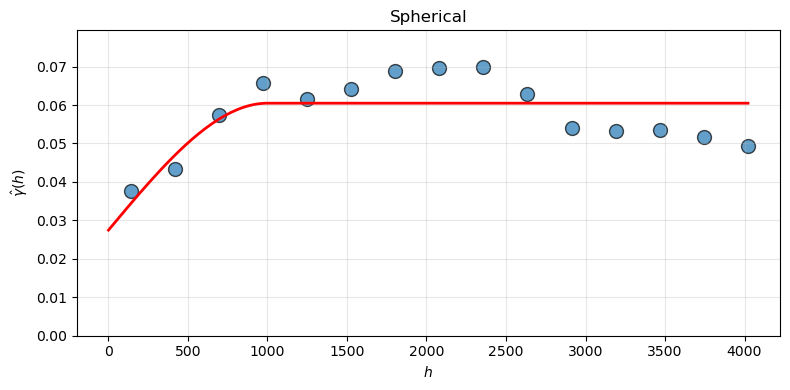

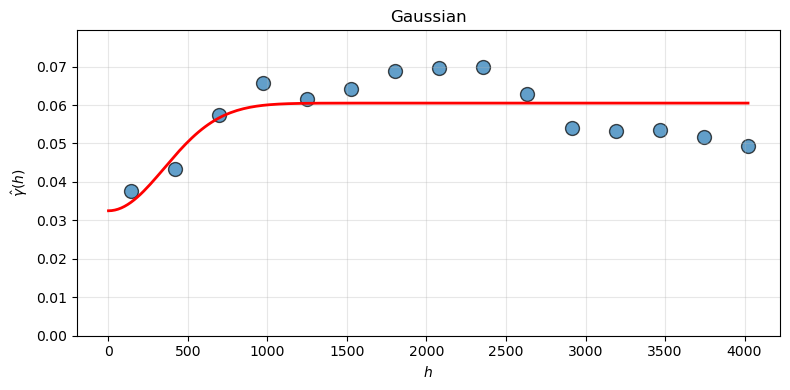

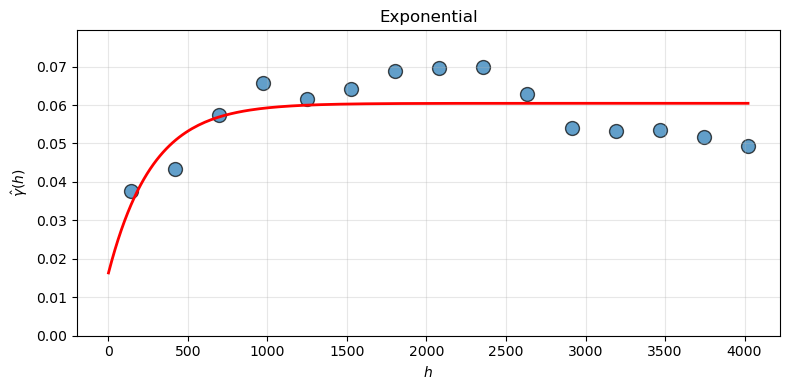

Model Results ----------------

Spherical Model RMSE: 0.007, R2: 0.277
Exponential Model RMSE: 0.007, R2: 0.236
Gaussian Model RMSE: 0.007, R2: 0.273


In [12]:
X = build_design_matrix_v2(
    latitude=latitude,
    obliquity_rad=orbital_today["obliquity_rad"],
    climatic_precession=orbital_today["eccentricity"] * np.sin(orbital_today["pibar_rad"])
)

beta, z_fitted, residuals, r2 = fit_trend_ols(X, y_variable)

lag_centers_r, gamma_hat_r, n_pairs_r = empirical_variogram(
    distance_matrix, residuals, n_bins=15
)

gaus_variables_r, gaus_cov_r = fit_variogram_model(gaussian_model, lag_centers_r, gamma_hat_r, n_pairs_r)
sph_variables_r, sph_cov_r = fit_variogram_model(spherical_model, lag_centers_r, gamma_hat_r, n_pairs_r)
exp_variables_r, exp_cov_r = fit_variogram_model(exponential_model, lag_centers_r, gamma_hat_r, n_pairs_r)

plot_variogram_curve(lag_centers_r, gamma_hat_r, n_pairs_r,
                      spherical_model, sph_variables_r,
                      title="Spherical")
plot_variogram_curve(lag_centers_r, gamma_hat_r, n_pairs_r,
                      gaussian_model, gaus_variables_r,
                      title="Gaussian")
plot_variogram_curve(lag_centers_r, gamma_hat_r, n_pairs_r,
                      exponential_model, exp_variables_r,
                      title="Exponential")

sph_residuals_r, _, sph_weighted_r2_r = variogram_residuals_r2(spherical_model, sph_variables_r, lag_centers_r, gamma_hat_r, n_pairs_r)
exp_residuals_r, _, exp_weighted_r2_r = variogram_residuals_r2(exponential_model, exp_variables_r, lag_centers_r, gamma_hat_r, n_pairs_r)
gaus_residuals_r, _, gaus_weighted_r2_r = variogram_residuals_r2(gaussian_model, gaus_variables_r, lag_centers_r, gamma_hat_r, n_pairs_r)

print("Model Results ----------------\n")
print(f"Spherical Model RMSE: {np.sqrt(np.mean(sph_residuals_r**2)):.3f}, R2: {sph_weighted_r2_r:.3f}")
print(f"Exponential Model RMSE: {np.sqrt(np.mean(exp_residuals_r**2)):.3f}, R2: {exp_weighted_r2_r:.3f}")
print(f"Gaussian Model RMSE: {np.sqrt(np.mean(gaus_residuals_r**2)):.3f}, R2: {gaus_weighted_r2_r:.3f}")

In [15]:
gaus_params_resid, gaus_pcov_resid = fit_variogram_model(
    gaussian_model, lag_centers_r, gamma_hat_r, n_pairs_r
)

Gamma = build_gamma_matrix(distance_matrix, gaussian_model, gaus_params_resid)
A = build_krigging_system(Gamma)
A_inv = np.linalg.inv(A)

resid_pred, resid_var = krige_grid(
    long_inside, lat_inside, longitude, latitude, residuals,
    gaussian_model, gaus_params_resid, A_inv
)

In [19]:
target_t = -1740

obliquity_174 = np.interp(target_t, la2004["t"].values[::-1], la2004["obliquity_rad"].values[::-1])
ecc_174 = np.interp(target_t, la2004["t"].values[::-1], la2004["eccentricity"].values[::-1])
pibar_174 = np.interp(target_t, la2004["t"].values[::-1], la2004["pibar_rad"].values[::-1])
precession_174 = ecc_174 * np.sin(pibar_174)

print(f"At 1.74 Ma: obliquity={np.degrees(obliquity_174):.4f} deg, "
      f"eccentricity={ecc_174:.5f}, climatic precession={precession_174:.5f}")

lat_inside_rad = np.radians(lat_inside)
trend_174 = (beta[0] +
                  beta[1] * precession_174 * np.sin(lat_inside_rad) +
                  beta[2] * obliquity_174 * np.abs(lat_inside_rad))

pred_174 = trend_174 + resid_pred

nodata_value = -9999.0

def reassemble_raster(values_inside, inside_mask, grid_shape, nodata_value):
    full = np.full(inside_mask.shape, nodata_value)
    full[inside_mask] = values_inside
    raster = full.reshape(grid_shape)
    raster = np.flipud(raster)  # north-up orientation for GeoTIFF convention
    return raster

raster_174 = reassemble_raster(pred_174, inside_mask, grid_long_mesh.shape, nodata_value)

transform = from_origin(minx, maxy, krigging_resolution, krigging_resolution)

def write_geotiff(filepath, raster, transform, nodata_value):
    with rasterio.open(
        filepath, "w",
        driver="GTiff",
        height=raster.shape[0],
        width=raster.shape[1],
        count=1,
        dtype=raster.dtype,
        crs="EPSG:4326",
        transform=transform,
        nodata=nodata_value,
    ) as dst:
        dst.write(raster, 1)
    print(f"Written: {filepath}")

write_geotiff("Krigging Phi/TempRatio_1_74Ma_reconstructed.tif", raster_174, transform, nodata_value)

At 1.74 Ma: obliquity=23.2441 deg, eccentricity=0.05295, climatic precession=-0.05097
Written: Krigging Phi/TempRatio_1_74Ma_reconstructed.tif


In [18]:
target_t = 0

obliquity_174 = np.interp(target_t, la2004["t"].values[::-1], la2004["obliquity_rad"].values[::-1])
ecc_174 = np.interp(target_t, la2004["t"].values[::-1], la2004["eccentricity"].values[::-1])
pibar_174 = np.interp(target_t, la2004["t"].values[::-1], la2004["pibar_rad"].values[::-1])
precession_174 = ecc_174 * np.sin(pibar_174)

print(f"At 1.74 Ma: obliquity={np.degrees(obliquity_174):.4f} deg, "
      f"eccentricity={ecc_174:.5f}, climatic precession={precession_174:.5f}")

lat_inside_rad = np.radians(lat_inside)
trend_174 = (beta[0] +
                  beta[1] * precession_174 * np.sin(lat_inside_rad) +
                  beta[2] * obliquity_174 * np.abs(lat_inside_rad))

pred_174 = trend_174 + resid_pred

nodata_value = -9999.0

def reassemble_raster(values_inside, inside_mask, grid_shape, nodata_value):
    full = np.full(inside_mask.shape, nodata_value)
    full[inside_mask] = values_inside
    raster = full.reshape(grid_shape)
    raster = np.flipud(raster)  # north-up orientation for GeoTIFF convention
    return raster

raster_174 = reassemble_raster(pred_174, inside_mask, grid_long_mesh.shape, nodata_value)

transform = from_origin(minx, maxy, krigging_resolution, krigging_resolution)

def write_geotiff(filepath, raster, transform, nodata_value):
    with rasterio.open(
        filepath, "w",
        driver="GTiff",
        height=raster.shape[0],
        width=raster.shape[1],
        count=1,
        dtype=raster.dtype,
        crs="EPSG:4326",
        transform=transform,
        nodata=nodata_value,
    ) as dst:
        dst.write(raster, 1)
    print(f"Written: {filepath}")

write_geotiff("Krigging Phi/TempRatio_reconstructed.tif", raster_174, transform, nodata_value)

At 1.74 Ma: obliquity=23.4393 deg, eccentricity=0.01670, climatic precession=0.01628
Written: Krigging Phi/TempRatio_reconstructed.tif
